In [1]:
import cv2
import os
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import shutil
from sklearn.cluster import KMeans
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# Feature Making

First, we need to make some features to describe the images so that we can perform clustering. We decided the most relevant features would be the number of corners, the number of concave corners, average side length and variation in side length, average distance from centroid and variation in average distance from centroid. While we are at it, we can also get the tight fitting box dimensions and the layout area.

In [14]:
def calculate_interior_angles_and_lengths(cnt, epsilon):
    # Approximate the contour to reduce the number of points
    approx = cv2.approxPolyDP(cnt, epsilon, True)

    # Calculate the number of points in the contour
    num_points = len(approx)

    # Calculate interior angles, vectors, and side lengths
    angles = []
    vectors = []
    side_lengths = []
    for i in range(num_points):
        pt1 = approx[i % num_points][0]
        pt2 = approx[(i + 1) % num_points][0]
        pt3 = approx[(i + 2) % num_points][0]

        v1 = pt1 - pt2
        v2 = pt3 - pt2

        # Calculate the cross product
        cross_product = np.cross(v1, v2)

        # Calculate the angle between the vectors
        angle = np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

        # Adjust the angle for concave angles
        if cross_product < 0:
            angle = 2 * np.pi - angle

        angles.append(np.degrees(angle))
        vectors.append((pt2, pt2 + v1, pt2 + v2))

        # Calculate the lengths of the sides
        side_lengths.append(np.linalg.norm(v1))

    return angles, vectors, side_lengths


def detect_corners(image_path):
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Image not found at {image_path}")

    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Parameters for Shi-Tomasi corner detection
    feature_params = {
        'maxCorners': 25,         # Maximum number of corners to return
        'qualityLevel': 0.012,    # Minimum accepted quality of image corners
        'minDistance': 3,         # Minimum possible Euclidean distance between the returned corners
        'blockSize': 8            # Size of an average block for computing a derivative covariation matrix over each pixel neighborhood
    }

    # Detect corners using the Shi-Tomasi Corner Detector
    corners = cv2.goodFeaturesToTrack(gray, **feature_params)

    if len(corners) == 25:
        new_feature_params = {
        'maxCorners': 25,         # Maximum number of corners to return
        'qualityLevel': 0.032,      # Minimum accepted quality of image corners
        'minDistance': 3,         # Minimum possible Euclidean distance between the returned corners
        'blockSize': 8             # Size of an average block for computing a derivative covariation matrix over each pixel neighborhood
        }
        corners = cv2.goodFeaturesToTrack(gray, **new_feature_params)
    
    # Count the number of corners detected
    num_corners = corners.shape[0] if corners is not None else 0

    return num_corners,corners


def distance_from_centroid(image_path):
    # Load the image
    img = cv2.imread(image_path)

    # Convert image to gray scale image
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect edges using Canny
    edges = cv2.Canny(gray, 30, 200)

    # Calculate centroid of edges
    M = cv2.moments(edges)
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])

    # Detect corners and count the number of corners
    num_corners, corners = detect_corners(image_path)

    # Calculate distances of each corner from centroid
    distances = []
    for corner in corners:
        x, y = corner.ravel()
        a = np.sqrt((cx - x) ** 2 + (cy - y) ** 2)
        distances.append(a)

    # Calculate average and standard deviation of distances
    avg_distance = np.mean(distances)
    std_distance = np.std(distances)

    return avg_distance, std_distance

#To get the tight fitting box dimensions and layout area
def tf_box_dim(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edged = cv2.Canny(gray, 30, 200)
    contours, _ = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contours, key=cv2.contourArea)
    
    area = cv2.contourArea(cnt)
    
    rect = cv2.minAreaRect(cnt)
    (cx, cy), (width, height), angle = rect
    
    return area, height, width


# Define the directory containing the images
image_dir = "E7-images"

# Initialize lists to store results
image_names = []
std_angles_list = []
std_lengths_list = []
num_corners_list = []
num_concave_corners_list = []
dist_from_centroid_avg_list = []
dist_from_centroid_std_list = []
layout_area = []
tf_box_height = []
tf_box_width = []

# Loop through each image in the directory
for filename in os.listdir(image_dir):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        # Load the image
        img = cv2.imread(os.path.join(image_dir, filename))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        edged = cv2.Canny(gray, 30, 200)
        contours, _ = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cnt = max(contours, key=cv2.contourArea)

        # Define the epsilon value for approximation
        epsilon = 0.003 * cv2.arcLength(cnt, True)

        # Calculate interior angles, vectors, and side lengths
        angles, _, side_lengths = calculate_interior_angles_and_lengths(cnt, epsilon)

        # Compute the standard deviation of angles and side lengths
        std_angles = np.std(angles)
        std_lengths = np.std(side_lengths)

        # Detect corners and count the number of corners
        num_corners, _ = detect_corners(os.path.join(image_dir, filename))

        # Calculate the number of concave corners (interior angles > 180 degrees)
        num_concave_corners = np.sum(np.array(angles) > 180)

        # Calculate distance from centroid
        avg_dist, std_dist = distance_from_centroid(os.path.join(image_dir, filename))
        
        area_layout, height, width = tf_box_dim(img)

        # Store results in lists
        image_names.append(filename)
        std_angles_list.append(std_angles)
        std_lengths_list.append(std_lengths)
        num_corners_list.append(num_corners)
        num_concave_corners_list.append(num_concave_corners)
        dist_from_centroid_avg_list.append(avg_dist)
        dist_from_centroid_std_list.append(std_dist)
        layout_area.append(area_layout)
        tf_box_height.append(height)
        tf_box_width.append(width)
        


# Create a DataFrame to store the results
data = {
    'Image Name': image_names,
    'Std of Angles': std_angles_list,
    'Std of Sides': std_lengths_list,
    'Number of Corners': num_corners_list,
    'Number of Concave Corners': num_concave_corners_list,
    'Avg Distance from Centroid': dist_from_centroid_avg_list,
    'Std Distance from Centroid': dist_from_centroid_std_list,
    'Layout Area': layout_area,
    'Height of TF Box': tf_box_height,
    'Width of TF Box': tf_box_width
}
df = pd.DataFrame(data)

# Save the DataFrame to an Excel file
excel_file = 'image_stats.xlsx'
df.to_excel(excel_file, index=False)

data_no_TF = {
    'Image Name': image_names,
    'Std of Angles': std_angles_list,
    'Std of Sides': std_lengths_list,
    'Number of Corners': num_corners_list,
    'Number of Concave Corners': num_concave_corners_list,
    'Avg Distance from Centroid': dist_from_centroid_avg_list,
    'Std Distance from Centroid': dist_from_centroid_std_list,
}

df_no_TF = pd.DataFrame(data_no_TF)
excel_file = 'image_stats_no_TF.xlsx'
df_no_TF.to_excel(excel_file, index=False)



print("Data saved to", excel_file)

Data saved to image_stats_no_TF.xlsx


In [3]:
features = pd.read_excel('image_stats.xlsx', sheet_name='Sheet1')

# K-Means Clustering

The first step is t-SNE (t-distributed stochastic neighbor embedding), a dimensionality reduction technique commonly used for visualizing high-dimensional data in a lower-dimensional space while preserving the structure of the data as much as possible. We then apply K-means clustering on the data obtained to get clusters. We assume there are roughly 25 families. Even if there aren't exactly 25 families, the images within a family will be similar enough.

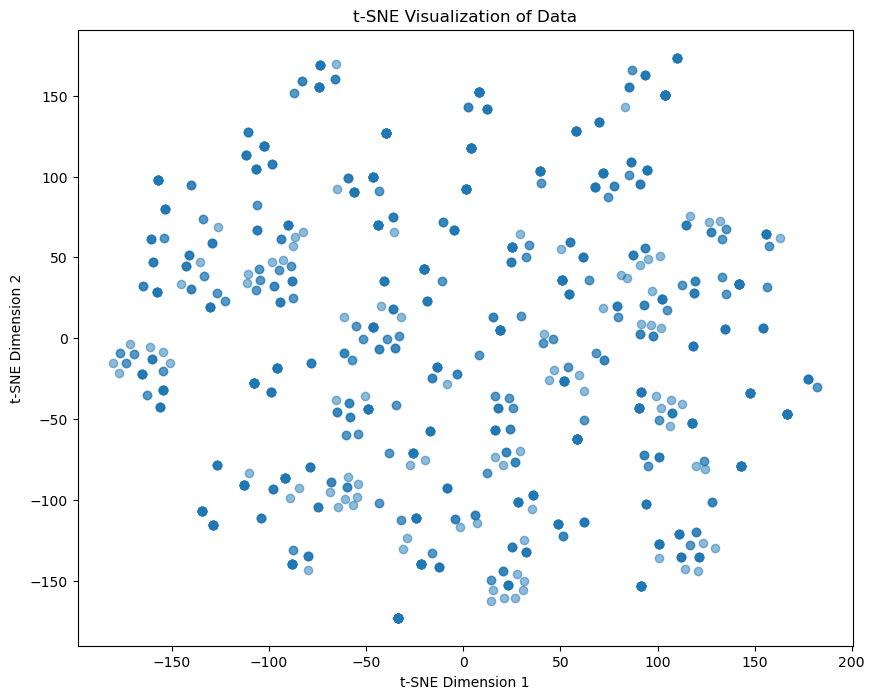

In [4]:
# Create data for clustering
data_for_tsne = features.drop(columns=['Image Name', 'Layout Area', 'Height of TF Box', 'Width of TF Box'])
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_tsne)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(scaled_data)
# Visualize clusters
plt.figure(figsize=(10, 8))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1], alpha=0.5)
plt.title('t-SNE Visualization of Data')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

/Users/vishesh/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


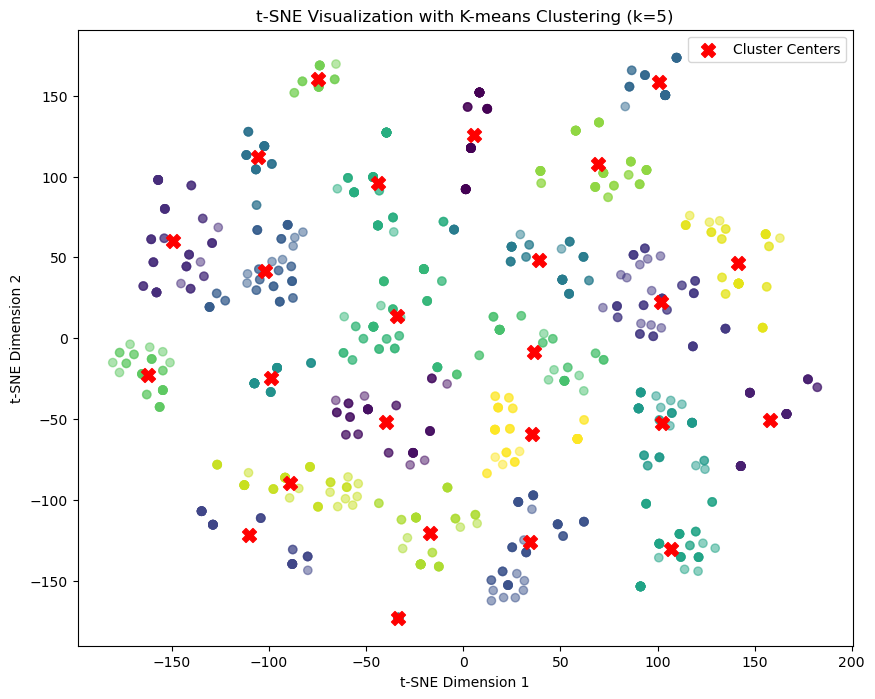

,Image Name,Std of Angles,Std of Sides,Number of Corners,Number of Concave Corners,Avg Distance from Centroid,Std Distance from Centroid,Layout Area,Height of TF Box,Width of TF Box,Cluster Label
0,0071.jpg,45.170199,84.845348,4,2,254.207548,8.847174,130779.5,452.015411,337.649902,12
1,0717.jpg,39.784124,143.718986,8,2,216.080994,29.997984,96694.5,336.609161,452.846588,21
2,0703.jpg,0.595572,59.557195,4,0,272.872781,2.048222,146617.0,450.278595,329.235260,7
3,0065.jpg,50.431992,62.041157,13,4,186.434156,36.924007,108172.5,454.893829,322.203217,20
4,0059.jpg,1.117977,56.906069,4,0,273.533744,2.406484,147924.5,453.092133,334.324768,3


In [5]:
# Apply K-means clustering
kmeans = KMeans(n_clusters=25, random_state=42)
cluster_labels = kmeans.fit_predict(tsne_data)
features['Cluster Label'] = cluster_labels

# Visualize clusters
plt.figure(figsize=(10, 8))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red', marker='X', label='Cluster Centers')
plt.title('t-SNE Visualization with K-means Clustering (k=5)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.show()
features.head()

In [6]:
l = 'E7-images'
destination_base = 'families'

os.makedirs(destination_base, exist_ok=True)

for i in range(25):
    # Create subdirectories for each category
    category_path = os.path.join(destination_base, str(i))
    os.makedirs(category_path, exist_ok=True)

    # Iterate over the files in the image directory
    for file in os.listdir(l):

        # Filter the DataFrame for the current file
        d = features[features['Image Name'] == file]
        if (d.iloc[0, 10] == i):
            # Copy the file to the corresponding category directory
            shutil.copy(os.path.join(l, file), category_path)

print("Files have been categorized and copied.")

Files have been categorized and copied.


# Heirarchial Clustering

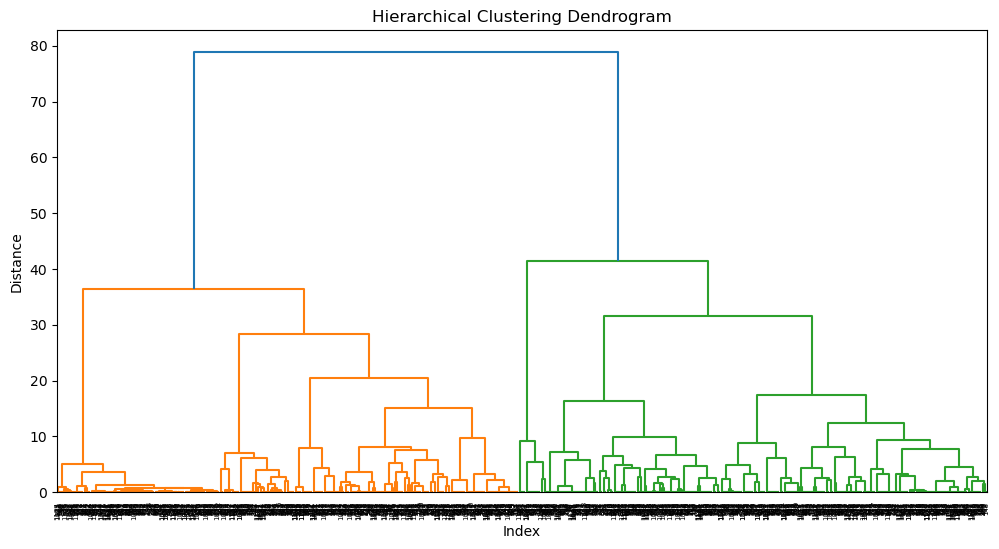

In [7]:
# Load the dataset
features2 = pd.read_excel("image_stats.xlsx")
features2 = features2.drop(columns=['Image Name', 'Layout Area', 'Height of TF Box', 'Width of TF Box'])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features2)
    
# Perform hierarchical clustering
Z = linkage(scaled_data, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Index")
plt.ylabel("Distance")
plt.show()

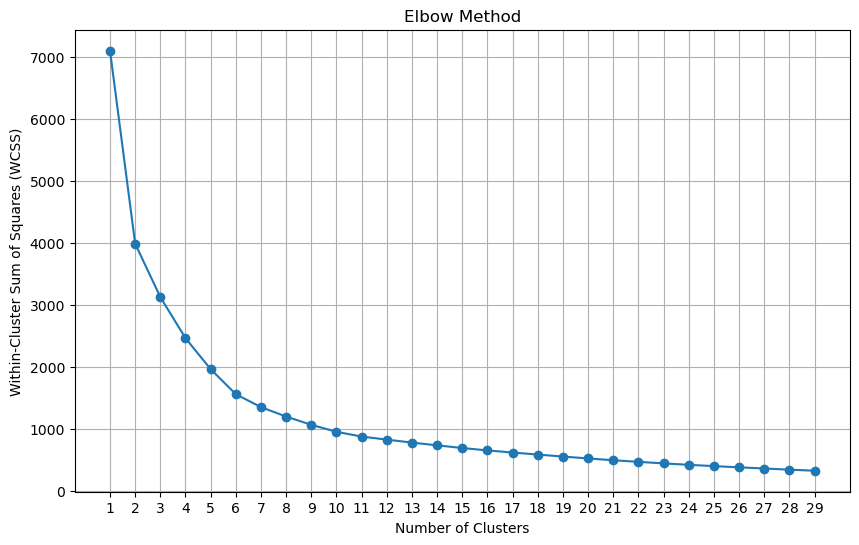

In [8]:
from scipy.cluster.hierarchy import fcluster

# Calculate the within-cluster sum of squares for different numbers of clusters
wcss = []
max_clusters = 30  # You can adjust this based on your dataset
for i in range(1, max_clusters):
    labels = fcluster(Z, i, criterion='maxclust')
    centroids = np.array([scaled_data[labels == j].mean(axis=0) for j in range(1, i+1)])
    wcss.append(np.sum((scaled_data - centroids[labels - 1]) ** 2))

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters), wcss, marker='o', linestyle='-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(np.arange(1, max_clusters, step=1))
plt.grid(True)
plt.show()

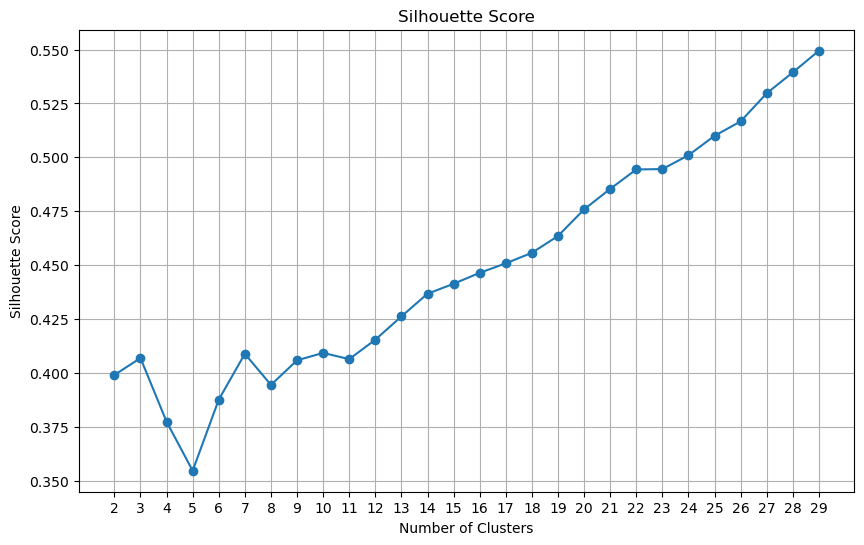

In [9]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score for different numbers of clusters
silhouette_scores = []
max_clusters = 30  # You can adjust this based on your dataset
for i in range(2, max_clusters):
    labels = fcluster(Z, i, criterion='maxclust')
    silhouette_scores.append(silhouette_score(scaled_data, labels))

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_clusters), silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(np.arange(2, max_clusters, step=1))
plt.grid(True)
plt.show()

26 clusters is a suitable assumption

In [10]:
# Build final model with 26 clusters
final_labels = fcluster(Z, 26, criterion='maxclust')

# Add the cluster labels to the original dataset
data_with_labels = features2.copy()
data_with_labels['Cluster'] = final_labels

If we were to assume that the clusters would be formed based on complexity, we could use clustering to label complexity. This approach was not followed though.

In [11]:
# data_with_labels.to_excel('data_with_labels.xlsx', index=False)
#final_labels = fcluster(Z, 3, criterion='maxclust')

# Add the cluster labels to the original dataset
#data_with_3labels = data.copy()
#data_with_3labels['Cluster'] = final_labels

# Display the first few rows of the dataset with cluster labels
#print(data_with_3labels.head())
#data_with_3labels.to_excel('data_with_3labels.xlsx', index=False)

# Appendix

Using Shi-Tomasi to find corners

Detected corners:
Corner 1: (149.0, 356.0)
Corner 2: (457.0, 409.0)
Corner 3: (161.0, 100.0)
Corner 4: (515.0, 118.0)
Corner 5: (552.0, 257.0)
Corner 6: (104.0, 199.0)
Corner 7: (439.0, 75.0)
Corner 8: (328.0, 403.0)
Corner 9: (328.0, 407.0)


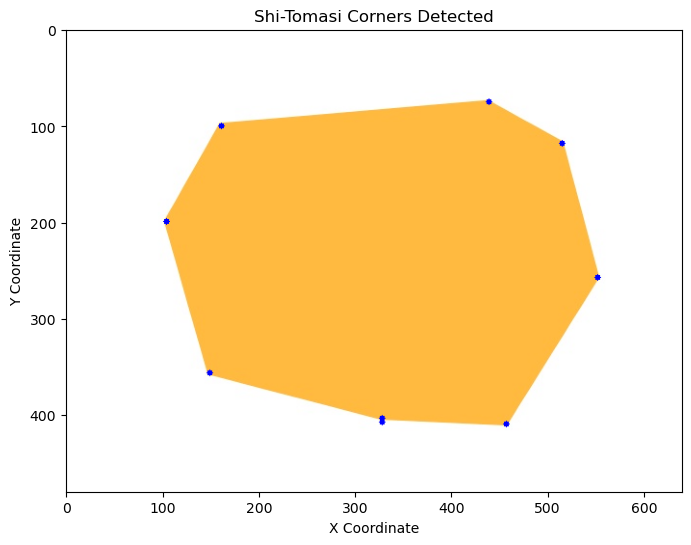

In [12]:
image_path = 'E7-images/0257.jpg'  # Make sure the path is correct
img = cv2.imread(image_path)
if img is None:
    raise ValueError(f"Image not found at {image_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Parameters for Shi-Tomasi corner detection
feature_params = {
    'maxCorners': 25,         # Maximum number of corners to return
    'qualityLevel': 0.012,      # Minimum accepted quality of image corners
    'minDistance': 3,         # Minimum possible Euclidean distance between the returned corners
    'blockSize': 8             # Size of an average block for computing a derivative covariation matrix over each pixel neighborhood
}

# Detect corners using the Shi-Tomasi Corner Detector
corners = cv2.goodFeaturesToTrack(gray, **feature_params)

if len(corners) == 25:
    new_feature_params = {
    'maxCorners': 25,         # Maximum number of corners to return
    'qualityLevel': 0.032,      # Minimum accepted quality of image corners
    'minDistance': 3,         # Minimum possible Euclidean distance between the returned corners
    'blockSize': 8             # Size of an average block for computing a derivative covariation matrix over each pixel neighborhood
    }
    corners = cv2.goodFeaturesToTrack(gray, **new_feature_params)

# Draw corners detected on the original image
if corners is not None:
    print("Detected corners:")
    for index, corner in enumerate(corners):
        x, y = corner.ravel()
        print(f"Corner {index + 1}: ({x}, {y})")

        # Draw corners detected on the original image
        cv2.circle(img, (int(x), int(y)), 3, (255, 0, 0), -1)

# Convert BGR image to RGB for plotting
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Using matplotlib to display the image with axes
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title('Shi-Tomasi Corners Detected')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(False)  # Set to True if you want a grid
plt.show()